In [1]:
!pip install sinabs

In [2]:
import numpy as np

folder_path = r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD"

int_id_data = np.load(folder_path + r"\int_id_data.npy", allow_pickle=True)
attack_labels = np.load(folder_path + r"\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(folder_path + r"\int_id_data_test.npy", allow_pickle=True)
attack_labels_test = np.load(folder_path + r"\attack_labels_test.npy", allow_pickle=True)

In [3]:
import builtins
import numpy as np


def sliding_windows_id_data(samples, labels, window_size=32, step=2, attack_labels=('T', 'D', 'F', 'S')):
    n = len(samples)

    if isinstance(attack_labels, str):
        attack_labels = (attack_labels,)

    windows = []
    window_labels = []
    next_id_datas = []
    

    for start in range(0, n - window_size, step):
        end = start + window_size
        window_slice = labels[start:end]

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])

        matching_attack = builtins.next(
            (label for label in attack_labels if label in window_slice),
            'R'
        )
        window_labels.append(matching_attack)

    return (
        np.array(windows, dtype=np.uint8),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

In [4]:
windows, windowed_labels = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data[i], attack_labels[i])
    windows.extend(windows_batch)
    windowed_labels.extend(windowed_labels_batch)


In [5]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels)), dtype=np.uint8)
attack_onehot[windowed_labels == 'T'] = 1

print(attack_onehot[:10])

[0 0 0 0 0 0 1 1 1 1]


In [6]:
windows_test, windowed_labels_test = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_test[i], attack_labels_test[i])
    windows_test.extend(windows_batch)
    windowed_labels_test.extend(windowed_labels_batch)

In [7]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test)), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'T'] = 1

print(attack_onehot_test[:10])

[1 1 1 1 1 1 0 1 1 1]


In [8]:
import torch
from torch.utils.data import Dataset


class CANDataset(Dataset):
    def __init__(
        self,
        windows,
        attack_onehot,
        train=True,
        is_spiking=False,
        time_window=100,
    ):
        # Convert to tensors
        self.windows = torch.as_tensor(windows, dtype=torch.float32)

        # Add channel dimension:
        # (N, H, W) -> (N, 1, H, W)
        if self.windows.ndim == 3:
            self.windows = self.windows.unsqueeze(1)

        self.labels = torch.as_tensor(attack_onehot, dtype=torch.long)

        self.is_spiking = is_spiking
        self.time_window = time_window

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        img = self.windows[index]
        label = self.labels[index]

        if self.is_spiking:
            # Optional normalization if inputs are not already in [0,1]
            #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            # Generate spike train
            img = (
                torch.rand(self.time_window, *img.shape) < img
            ).float()

        return img, label

In [9]:
windows = np.array(windows)
print(windows.shape)
print(windows.dtype)
print(windows.min(), windows.max())

print(windows[0])

windows_test = np.array(windows_test)
print(windows_test.shape)
print(windows_test.dtype)
print(windows_test.min(), windows_test.max())

print(windows_test[0])

(2229345, 32, 10)
uint8
0 255
[[  5 225 137  53   0  11   9 255 236 128]
 [  2 139   0   0   0   0   0   0   0   0]
 [  0 208  10 119   4  96 241   3   7   0]
 [  0  51   0   6  80   0  12  67  23 208]
 [  1  37 144   0  64 223  64  63 111  96]
 [  0 167   0  16 248 164 225  46   0 160]
 [  2 210   0   0  24   0   0   0   0   0]
 [  2 180  20 234  86   0   0   0  88   0]
 [ 15 255   0   0   0   0   0   0   0   0]
 [  4 203 128   0   0   0   0   0   0   0]
 [  2 128  24   2   2   0   0   0   0   0]
 [  0  14  32  82 214   2   8   9 117  96]
 [  4 253  17  52  10  79  71  10  74   8]
 [ 15 255   0   0   0   0   0   0   0   0]
 [ 15 255   0   0   0   0   0   0   0   0]
 [  0 244 154  12   1   2   4 177   2  64]
 [  3  45   0   0   4  32 172   1   0  32]
 [  1 147   0   8   8   3 231 216   0   0]
 [  2  14  78  32   3 161 132 191 143 247]
 [  5  34 223 127 208   0 123 192   0  28]
 [  3 102 126 157 200   2   1  71 206  56]
 [  5 128   0   0   0   6 124   7 250 144]
 [  4  52   1 104  96 17

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

windows = scaler.fit_transform(
    windows.reshape(-1, windows.shape[-1])
).reshape(windows.shape)

windows_test = scaler.transform(
    windows_test.reshape(-1, windows_test.shape[-1])
).reshape(windows_test.shape)

In [11]:
from torch.utils.data import DataLoader

canbus_train = CANDataset(windows, attack_onehot, train=True, is_spiking=False)
train_loader = DataLoader(canbus_train, batch_size=256, shuffle=True)

canbus_test = CANDataset(windows_test, attack_onehot_test, train=False, is_spiking=False)
test_loader = DataLoader(canbus_test, batch_size=256, shuffle=False)

In [12]:
import torch.nn as nn

ann = nn.Sequential(
    # Input: (1, 32, 10)

    nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=(3, 3),
        stride=1,
        padding=0,
        bias=True
    ),
    nn.ReLU(),

    # Output: (32, 30, 8)

    nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

    # Output: (32, 15, 4)

    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=(3, 3),
        stride=1,
        padding=0,
        bias=True
    ),
    nn.ReLU(),

    # Output: (64, 13, 2)

    nn.Flatten(),

    # 64 × 13 × 2 = 1664 features
    nn.Linear(1664, 64),
    nn.ReLU(),

    nn.Linear(64, 4)
    # No Softmax here when using CrossEntropyLoss
)

In [13]:
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

ann = ann.to(device)
ann.train()

optimizer = torch.optim.Adam(ann.parameters(), lr=1e-3)

n_epochs = 2

for epoch in range(n_epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")

    for batch_idx, (data, target) in enumerate(progress_bar):

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = ann(data)

        loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer.step()

        # Update loss
        running_loss += loss.item()

        # Predictions
        pred = output.argmax(dim=1)

        # Update accuracy
        correct += (pred == target).sum().item()
        total += target.size(0)

        accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{running_loss/(batch_idx+1):.4f}",
            acc=f"{accuracy:.2f}%"
        )

    print(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/2:   0%|          | 0/8709 [00:00<?, ?it/s]

Epoch 1/2 | Loss: 0.0800 | Accuracy: 96.79%


Epoch 2/2:   0%|          | 0/8709 [00:00<?, ?it/s]

Epoch 2/2 | Loss: 0.0156 | Accuracy: 99.43%


In [14]:
correct_predictions = []

ann.eval()

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = ann(data)

        pred = output.argmax(dim=1)

        correct_predictions.append(pred == target)

correct_predictions = torch.cat(correct_predictions)

print(f"Accuracy = {100 * correct_predictions.float().mean():.2f}%")

Accuracy = 97.27%


In [30]:
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

ann.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        output = ann(data)

        pred = output.argmax(dim=1)

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Concatenate all batches
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_targets).numpy()

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1 score: {f1:.4f}")

# -------------------------
# Classification report
# -------------------------

class_names = ["R", "T"]      # Change if using more classes

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2,
        zero_division=0,
    )
)

# -------------------------
# Confusion matrix
# -------------------------

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion matrix:")
print(cm_df)

# -------------------------
# False Positive Rate
# -------------------------

print("\nFalse positive rate per class:")
for i, cls in enumerate(class_names):
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    fpr = fp / (fp + tn) if (fp + tn) else 0
    print(f"  {cls}: {fpr:.4f}")

# -------------------------
# False Negative Rate
# -------------------------

print("\nFalse negative rate per class:")
for i, cls in enumerate(class_names):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f"  {cls}: {fnr:.4f}")

Accuracy: 0.9727
Weighted precision: 0.9726
Weighted recall: 0.9727
Weighted F1 score: 0.9726

Classification report:
              precision    recall  f1-score   support

           R       0.98      0.98      0.98    412496
           T       0.95      0.94      0.95    144502

    accuracy                           0.97    556998
   macro avg       0.97      0.96      0.96    556998
weighted avg       0.97      0.97      0.97    556998


Confusion matrix:
        R       T
R  405865    6631
T    8578  135924

False positive rate per class:
  R: 0.0594
  T: 0.0161

False negative rate per class:
  R: 0.0161
  T: 0.0594


In [15]:
from sinabs.from_torch import from_model

input_shape = (1, 32, 10)
num_timesteps = 100  # per sample

sinabs_model = from_model(
    ann, input_shape=input_shape, add_spiking_output=True, synops=False, num_timesteps=num_timesteps
)

In [16]:
sinabs_model.spiking_model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (4): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=1664, out_features=64, bias=True)
  (7): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (8): Linear(in_features=64, out_features=4, bias=True)
  (spike_output): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
)

In [17]:
test_batch_size = 10

spike_mnist_test = CANDataset(
    windows_test, attack_onehot_test, train=False, is_spiking=True, time_window=num_timesteps
)
spike_test_loader = DataLoader(
    spike_mnist_test, batch_size=test_batch_size, shuffle=True
)

In [28]:
import sinabs.layers as sl
import torch
from tqdm import tqdm

correct_predictions = []

for data, target in tqdm(spike_test_loader):
    data, target = data.to(device), target.to(device)


    data = sl.FlattenTime()(data)

    with torch.no_grad():
        output = sinabs_model(data)

        output = output.unflatten(
            0,
            (target.shape[0], output.shape[0] // target.shape[0])
        )

    # Sum spikes over time and predict class
    pred = output.sum(1).argmax(dim=1)

    # Compare predictions with targets
    correct_predictions.append(pred.eq(target))

    # Stop after ~300 samples if desired
    if sum(len(x) for x in correct_predictions) >= 300:
        break

correct_predictions = torch.cat(correct_predictions)

accuracy = correct_predictions.float().mean().item() * 100

print(f"Classification accuracy: {accuracy:.2f}%")

  0%|          | 29/55700 [00:03<1:57:00,  7.93it/s]

Classification accuracy: 95.00%


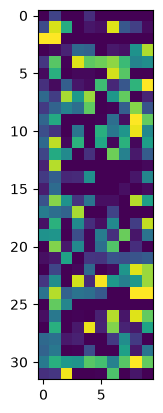

In [26]:
img, label = spike_mnist_test[10]

import matplotlib.pyplot as plt

%matplotlib inline

plt.imshow(img.sum(0)[0]);

In [29]:
import sinabs.layers as sl
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

sinabs_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in tqdm(spike_test_loader):

        data = data.to(device)
        target = target.to(device)

        # Flatten time and batch dimensions
        data = sl.FlattenTime()(data)

        output = sinabs_model(data)

        # Restore batch and time dimensions
        output = output.unflatten(
            0,
            (target.shape[0], output.shape[0] // target.shape[0])
        )

        # Sum spikes over time
        pred = output.sum(1).argmax(dim=1)

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Concatenate all batches
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_targets).numpy()

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1 score: {f1:.4f}")

# -------------------------
# Classification report
# -------------------------

class_names = ["R", "T"]       # Change if using 4 classes

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2,
        zero_division=0,
    )
)

# -------------------------
# Confusion matrix
# -------------------------

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion matrix:")
print(cm_df)

# -------------------------
# False Positive / Negative Rates
# -------------------------

print("\nFalse positive rate per class:")
for i, cls in enumerate(class_names):
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    fpr = fp / (fp + tn) if (fp + tn) else 0
    print(f"  {cls}: {fpr:.4f}")

print("\nFalse negative rate per class:")
for i, cls in enumerate(class_names):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f"  {cls}: {fnr:.4f}")

100%|██████████| 55700/55700 [1:51:55<00:00,  8.29it/s]  


Accuracy: 0.9528
Weighted precision: 0.9524
Weighted recall: 0.9528
Weighted F1 score: 0.9524

Classification report:
              precision    recall  f1-score   support

           R       0.96      0.98      0.97    412496
           T       0.93      0.89      0.91    144502

    accuracy                           0.95    556998
   macro avg       0.94      0.93      0.94    556998
weighted avg       0.95      0.95      0.95    556998


Confusion matrix:
        R       T
R  402562    9934
T   16368  128134

False positive rate per class:
  R: 0.1133
  T: 0.0241

False negative rate per class:
  R: 0.0241
  T: 0.1133
